# Models analyses

Import models and testing set

In [15]:
import pickle
from pathlib import Path

model_paths = {
    "RF no-odds": Path("../models/rf_no_odds_model.pkl"),
    "RF with-odds": Path("../models/rf_with_odds_model.pkl"),
    "XGB no-odds": Path("../models/xgb_no_odds_model.pkl"),
    "XGB with-odds": Path("../models/xgb_with_odds_model.pkl"),
}

models = {}
for name, path in model_paths.items():
    with open(path, "rb") as f:
        models[name] = pickle.load(f)


In [16]:
import numpy as np, pandas as pd
from IPython.display import display

TESTING_PATH = "../data/testing/tennis_testing.xlsx"

test_set = pd.read_excel(TESTING_PATH)

target = "y"
y_test = test_set[target]

print(f"Loaded prepared test set with {len(test_set)} rows")


Loaded prepared test set with 16539 rows


### Baselines

In [17]:
def baseline_accuracy(name, prediction, valid_mask, y_test):
    """Accuracy of a prediction rule, computed only on matches where it applies."""
    accuracy = (prediction[valid_mask] == y_test[valid_mask]).mean()
    coverage = valid_mask.mean()
    print(f"{name}: {accuracy:.2%}  (coverage: {coverage:.1%})")


# Majority class: whichever class (0 or 1) is more common in the test set.
maj_acc = y_test.value_counts().max() / y_test.value_counts().sum()
print(f"Majority class: {maj_acc:.2%}")

baseline_accuracy("Ranking", test_set["Rank_Log_Ratio"] > 0, test_set["Rank_Log_Ratio"].notna(), y_test)
baseline_accuracy("Points", test_set["Points_Log_Ratio"] > 0, test_set["Points_Log_Ratio"].notna(), y_test)

valid_odds = test_set["Odds_1"].notna() & test_set["Odds_2"].notna() & (test_set["Odds_1"] != test_set["Odds_2"])
baseline_accuracy("Market (odds)", test_set["Odds_1"] < test_set["Odds_2"], valid_odds, y_test)


Majority class: 50.14%
Ranking: 63.72%  (coverage: 99.8%)
Points: 63.45%  (coverage: 99.8%)
Market (odds): 68.42%  (coverage: 97.1%)


### Model Evaluation

In [18]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    log_loss,
    roc_auc_score,
    brier_score_loss,
    f1_score,
)

def get_model_data(model, test_set):
    model_features = list(model.feature_names_in_)
    X = test_set[model_features]
    y = test_set["y"]
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return model_features, X, y, proba, pred

def evaluate_model(name, model, test_set):
    model_features, X, y, proba, pred = get_model_data(model, test_set)

    metrics = {
        "Accuracy": accuracy_score(y, pred),
        "F1-Score": f1_score(y, pred),
        "ROC AUC": roc_auc_score(y, proba),
        "Log loss": log_loss(y, proba),
        "Brier Score": brier_score_loss(y, proba),
    }

    return {
        "name": name,
        "features": model_features,
        "X": X,
        "y": y,
        "proba": proba,
        "pred": pred,
        "metrics": metrics,
    }

results = {name: evaluate_model(name, model, test_set) for name, model in models.items()}

results_df = pd.DataFrame({name: r["metrics"] for name, r in results.items()}).T
display(results_df)

,Accuracy,F1-Score,ROC AUC,Log loss,Brier Score
RF no-odds,0.649616,0.644413,0.713617,0.617195,0.214920
RF with-odds,0.672411,0.669231,0.740957,0.596307,0.205743
XGB no-odds,0.653183,0.650457,0.716824,0.615865,0.214302
XGB with-odds,0.679183,0.678541,0.745949,0.592065,0.203915


### Feature Usage

In [19]:
def source_feature_name(transformed_name, model_features):
    # Map one-hot / missing-indicator names back to their source column.
    prefix, _, rest = transformed_name.partition("__")
    if prefix not in ("num", "cat", "high_cardinality"):
        return transformed_name

    encoded = rest.removeprefix("missingindicator_")
    for feature in model_features:
        if encoded == feature or encoded.startswith(f"{feature}_"):
            return feature
    return encoded


def feature_usage(name, model, top_n=15):
    model_features = list(model.feature_names_in_)
    transformed_names = model[:-1].get_feature_names_out()
    estimator = model.named_steps["model"]

    usage = pd.DataFrame({
        "Feature": transformed_names,
        "Importance": estimator.feature_importances_,
    })
    usage["Source_Feature"] = usage["Feature"].map(lambda f: source_feature_name(f, model_features))

    usage_by_source = (
        usage.groupby("Source_Feature", as_index=False)["Importance"]
        .sum()
        .sort_values("Importance", ascending=False)
    )

    print(f"{name} feature usage")
    display(usage_by_source.head(top_n))


for name, model in models.items():
    feature_usage(name, model)

RF no-odds feature usage


,Source_Feature,Importance
13,Surface_Elo_Diff,0.302049
8,Points_Diff,0.224463
9,Rank_Diff,0.169445
3,Dominance_Form_Diff,0.156292
10,Recent_Surface_Form_Diff,0.046687
4,Fatigue_Diff,0.022527
0,Age_Diff,0.020506
12,Series,0.015164
5,H2H_Surface_Diff,0.014770
11,Round,0.011743


RF with-odds feature usage


,Source_Feature,Importance
8,Odds_Diff,0.331151
14,Surface_Elo_Diff,0.191274
9,Points_Diff,0.142267
3,Dominance_Form_Diff,0.113880
10,Rank_Diff,0.113141
11,Recent_Surface_Form_Diff,0.034073
4,Fatigue_Diff,0.018036
0,Age_Diff,0.017763
13,Series,0.010482
12,Round,0.008111


XGB no-odds feature usage


,Source_Feature,Importance
13,Surface_Elo_Diff,0.238013
12,Series,0.162167
11,Round,0.156780
8,Points_Diff,0.090036
9,Rank_Diff,0.064129
7,Home_Advantage,0.043911
3,Dominance_Form_Diff,0.043805
6,Hand_Advantage,0.037786
0,Age_Diff,0.036788
2,Court,0.034299


XGB with-odds feature usage


,Source_Feature,Importance
8,Odds_Diff,0.349554
14,Surface_Elo_Diff,0.308519
10,Rank_Diff,0.129759
9,Points_Diff,0.117271
3,Dominance_Form_Diff,0.044860
0,Age_Diff,0.013539
11,Recent_Surface_Form_Diff,0.011443
13,Series,0.008799
2,Court,0.008478
1,Best_of_5,0.007777


### Feature distribution

In [20]:
def plot_feature_distribution(name, res, test_set):
    comparison_df = pd.DataFrame({
        "Correct": res["pred"] == res["y"],
        "Surface_Elo_Diff": test_set["Surface_Elo_Diff"],
        "Odds_Diff": test_set["Odds_Diff"],
        "Ranking_Diff": test_set["Rank_Diff"]
    })
    
    print(f"\n--- {name}: Feature Distribution (Correct vs Wrong) ---")
    display(comparison_df.groupby("Correct")[["Surface_Elo_Diff", "Odds_Diff", "Ranking_Diff"]].describe())
    
# for name, res in results.items():
    # plot_feature_distribution(name, res, test_set)
    
plot_feature_distribution("XGB no-odds", results["XGB no-odds"], test_set)


--- XGB no-odds: Feature Distribution (Correct vs Wrong) ---


Surface_Elo_Diff                                                \
                   count      mean         std         min         25%   
Correct                                                                  
False             5736.0  2.495843  153.040235 -742.985719  -94.675899   
True             10803.0  0.156381  214.392918 -818.906305 -145.024575   

                                          Odds_Diff                      \
              50%         75%         max     count      mean       std   
Correct                                                                   
False    3.849796  100.772762  621.261008    5705.0 -0.022610  1.969002   
True     0.000000  148.295744  799.247701   10763.0  0.028015  4.962410   

                                       Ranking_Diff                        \
           min   25%  50%   75%    max        count      mean         std   
Correct                                                                     
False   -27.99 -0.97  0.0  0.84  21.99       5726.0 -1.729130  104.801764   
True    -66.00 -1.84  0.0  1.60  66.00      10781.0 -1.738892  167.620505   

                                          
            min   25%  50%   75%     max  
Correct                                   
False   -1093.0 -36.0 -2.0  34.0  1162.0  
True    -3381.0 -44.0 -1.0  44.0  4911.0

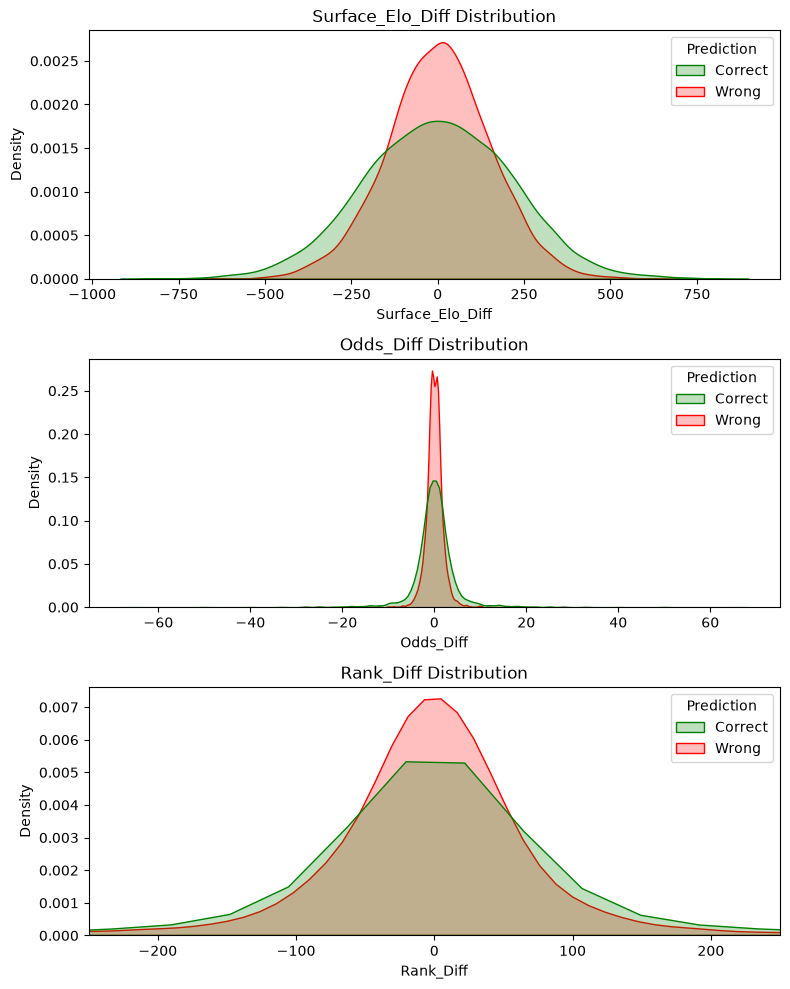

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

res = results["XGB no-odds"]

comp_df = pd.DataFrame({
    "Prediction": ["Correct" if p == y else "Wrong" for p, y in zip(res["pred"], res["y"])],
    "Surface_Elo_Diff": test_set["Surface_Elo_Diff"],
    "Odds_Diff": test_set["Odds_Diff"],
    "Rank_Diff": test_set["Rank_Diff"],
    "Surface": test_set["Surface"],  
    "Series": test_set["Series"]     
})

features = ["Surface_Elo_Diff", "Odds_Diff", "Rank_Diff"]
fig, axes = plt.subplots(3, 1, figsize=(8, 10))

for ax, feat in zip(axes, features):
    sns.kdeplot(
        data=comp_df,
        x=feat,
        hue="Prediction",
        fill=True,
        common_norm=False,
        palette={"Correct": "green", "Wrong": "red"},
        ax=ax
    )
    ax.set_title(f"{feat} Distribution")
    ax.set_ylabel("Density")
    
    # Zoom in on Rank_Diff to remove extreme outliers
    if feat == "Rank_Diff":
        ax.set_xlim(-250, 250)

plt.tight_layout()
plt.show()

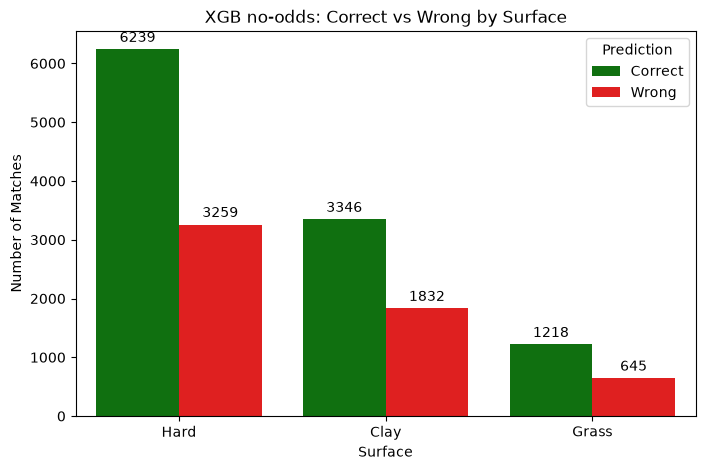

--- Accuracy by Surface ---
Surface
Hard     65.69%
Grass    65.38%
Clay     64.62%
Name: Correct, dtype: str




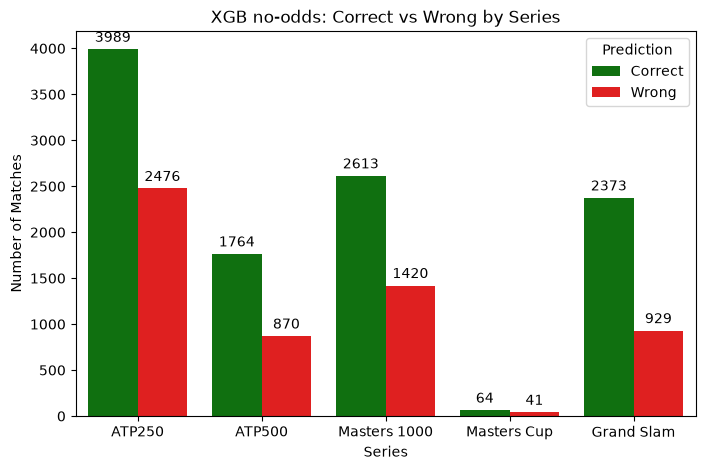

--- Accuracy by Series ---
Series
Grand Slam      71.87%
ATP500          66.97%
Masters 1000    64.79%
ATP250           61.7%
Masters Cup     60.95%
Name: Correct, dtype: str




In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Grafici a barre per le feature categoriche con NUMERI ESATTI
categorical_feats = ["Surface", "Series"]
for feat in categorical_feats:
    plt.figure(figsize=(8, 5))
    ax = sns.countplot(data=comp_df, x=feat, hue="Prediction", palette={"Correct": "green", "Wrong": "red"})
    
    # Questo ciclo aggiunge il numero esatto sopra le barre
    for container in ax.containers:
        ax.bar_label(container, padding=3, fmt='%d')
        
    plt.title(f"XGB no-odds: Correct vs Wrong by {feat}")
    plt.xlabel(feat)
    plt.ylabel("Number of Matches")
    plt.show()

    # Calcolo extra: stampa l'accuratezza per ogni categoria
    print(f"--- Accuracy by {feat} ---")
    accuracy_df = comp_df.groupby(feat)['Prediction'].value_counts(normalize=True).unstack() * 100
    if 'Correct' in accuracy_df.columns:
        print(accuracy_df['Correct'].sort_values(ascending=False).round(2).astype(str) + '%')
    print("\n")

### Most Confident Wrong Matches

In [23]:
def show_most_wrong(name, results, test_set, top_n=10):
    """Show the model's most confident WRONG predictions — useful to spot where it fails."""
    predicted_player_1 = results["pred"] == 1

    wrong = pd.DataFrame({
        "Actual_Winner": np.where(results["y"] == 1, test_set["Player_1"], test_set["Player_2"]),
        "Predicted_Winner": np.where(predicted_player_1, test_set["Player_1"], test_set["Player_2"]),
        "P1": test_set["Player_1"],
        "P2": test_set["Player_2"],
        "Rank_Diff": test_set["Rank_Diff"],
        "Rank1": test_set["Rank_1"],
        "Rank2": test_set["Rank_2"],
        "Surface_Elo_Diff": test_set["Surface_Elo_Diff"],
        # "Odds_Diff": test_set["Odds_Diff"],
        "Confidence": np.where(predicted_player_1, results["proba"], 1 - results["proba"]),
        "Date": test_set["Date"],
    }, index=test_set.index)

    wrong = wrong[results["y"] != results["pred"]]
    wrong = wrong.sort_values("Confidence", ascending=False).head(top_n)

    print(f"{name}: most confident wrong matches")
    display(wrong)


pd.set_option("display.max_columns", None)

# for name, model in models.items():
    # show_most_wrong(name, results[name], test_set)
    
show_most_wrong("XGB no-odds", results["XGB no-odds"], test_set, 5)

XGB no-odds: most confident wrong matches


,Actual_Winner,Predicted_Winner,P1,P2,Rank_Diff,Rank1,Rank2,Surface_Elo_Diff,Confidence,Date
15817,cerundolo j.m.,sinner j.,sinner j.,cerundolo j.m.,-55.0,1.0,56.0,581.955845,0.974020,2026-05-28
4456,vesely j.,djokovic n.,vesely j.,djokovic n.,122.0,123.0,1.0,-674.833960,0.962891,2022-02-24
9900,nardi l.,djokovic n.,nardi l.,djokovic n.,122.0,123.0,1.0,-742.985719,0.960991,2024-03-12
7817,seyboth wild t.,medvedev d.,seyboth wild t.,medvedev d.,170.0,172.0,2.0,-350.281449,0.959466,2023-05-30
10831,comesana f.,rublev a.,rublev a.,comesana f.,-116.0,6.0,122.0,388.193006,0.956139,2024-07-02


### Most Confident Correct Matches

In [24]:
def show_most_correct(name, results, test_set, top_n=10):
    """Show the model's most confident CORRECT predictions."""
    predicted_player_1 = results["pred"] == 1

    correct = pd.DataFrame({
        "Actual_Winner": np.where(results["y"] == 1, test_set["Player_1"], test_set["Player_2"]),
        "Predicted_Winner": np.where(predicted_player_1, test_set["Player_1"], test_set["Player_2"]),
        "P1": test_set["Player_1"],
        "P2": test_set["Player_2"],
        "Ranking_Diff": test_set["Rank_Diff"],
        "Confidence": np.where(predicted_player_1, results["proba"], 1 - results["proba"]),
        "Surface_Elo_Diff": test_set["Surface_Elo_Diff"],
        # "Odds_Diff": test_set["Odds_Diff"],
        "Date": test_set["Date"],
    }, index=test_set.index)

    correct = correct[results["y"] == results["pred"]]
    correct = correct.sort_values("Confidence", ascending=False).head(top_n)

    print(f"{name}: most confident correct matches")
    display(correct)


pd.set_option("display.max_columns", None)

# for name, model in models.items():
    # show_most_correct(name, results[name], test_set)
    
show_most_correct("XGB no-odds", results["XGB no-odds"], test_set, 5)

XGB no-odds: most confident correct matches


,Actual_Winner,Predicted_Winner,P1,P2,Ranking_Diff,Confidence,Surface_Elo_Diff,Date
1060,djokovic n.,djokovic n.,berankis r.,djokovic n.,65.0,0.981585,-675.017175,2020-10-01
14008,sinner j.,sinner j.,kopriva v.,sinner j.,88.0,0.981037,-818.906305,2025-08-26
10502,alcaraz c.,alcaraz c.,wolf j.j.,alcaraz c.,104.0,0.980777,-515.042427,2024-05-26
13141,alcaraz c.,alcaraz c.,alcaraz c.,zeppieri g.,-308.0,0.980606,658.740665,2025-05-26
243,nadal r.,nadal r.,dellien h.,nadal r.,72.0,0.980404,-600.912506,2020-01-21


Testing accuracy for best ranking players

In [25]:
market_pred = (test_set["Odds_1"] < test_set["Odds_2"]).to_numpy()
market_valid = test_set["Odds_1"].notna() & test_set["Odds_2"].notna()

for top_n in [10, 50, 100]:
    both_top = (test_set["Rank_1"] <= top_n) & (test_set["Rank_2"] <= top_n)
    mask = both_top & market_valid
    
    market_acc = (market_pred[mask] == y_test[mask]).mean()
    print(f"\n--- Top {top_n} (n={mask.sum()}) | Market: {market_acc:.2%} ---")
    
    # Iterate through all evaluated models
    for name, res in results.items():
        model_acc = (res["pred"][mask] == y_test[mask]).mean()
        print(f"{name}: {model_acc:.2%}")


--- Top 10 (n=349) | Market: 65.33% ---
RF no-odds: 65.04%
RF with-odds: 65.04%
XGB no-odds: 64.18%
XGB with-odds: 65.90%

--- Top 50 (n=4022) | Market: 68.03% ---
RF no-odds: 66.24%
RF with-odds: 67.11%
XGB no-odds: 65.59%
XGB with-odds: 68.10%

--- Top 100 (n=10394) | Market: 67.51% ---
RF no-odds: 65.04%
RF with-odds: 67.00%
XGB no-odds: 65.13%
XGB with-odds: 67.39%


Testing accuracy for Grand Slam tournaments

In [26]:
grand_slam_mask = (test_set["Series"] == "Grand Slam") & market_valid

market_acc_gs = (market_pred[grand_slam_mask] == y_test[grand_slam_mask]).mean()
print(f"--- Grand Slam (n={grand_slam_mask.sum()}) | Market: {market_acc_gs:.2%} ---")

for name, res in results.items():
    model_acc_gs = (res["pred"][grand_slam_mask] == y_test[grand_slam_mask]).mean()
    print(f"{name}: {model_acc_gs:.2%}")

--- Grand Slam (n=3299) | Market: 74.33% ---
RF no-odds: 71.08%
RF with-odds: 73.72%
XGB no-odds: 71.87%
XGB with-odds: 74.42%
